#### Imports and Setups

This cell imports the libraries used for data loading, plotting, file handling, display helpers, Neo4j access, and text processing.


In [ ]:
# importing libraries
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from pathlib import Path
import re

This cell configures pandas to display full column values instead of truncating long text.


In [10]:
# Setups
pd.set_option("display.max_colwidth", None)

This cell defines the folder where Tranco list figures will be saved and creates it if needed.


In [11]:
# setting figure directory 
fig_dir = Path.cwd().parent / "outputs" / "figures" / "tranco_list" 
fig_dir.mkdir(parents=True, exist_ok=True)

#### Loading Data

This cell loads the saved dependency parquet files for different TLD groups and keeps the domain and nameserver columns needed for this analysis.


In [ ]:
# loading dependency parquet files
base_dir = Path.cwd().parent / "data" / "result" / "dns_dependency"

try:
    gTLD_summary_df = pd.read_parquet(base_dir / "gTLD_domains_dependency_no_parent.parquet",columns=["domain","domain_unique_ns"] )
    
    ccTLD_summary_df = pd.read_parquet(base_dir / "ccTLD_domains_dependency_no_parent.parquet", columns=["domain","domain_unique_ns"] )
    
    genTLD_summary_df = pd.read_parquet(base_dir / "gen_resTLD_domains_dependency_no_parent.parquet", columns=["domain","domain_unique_ns"] )
    
    infTLD_summary_df = pd.read_parquet(base_dir / "infrTLD_domains_dependency_no_parent.parquet", columns=["domain","domain_unique_ns"] )
    
    sponTLD_summary_df = pd.read_parquet(base_dir / "sponTLD_domains_dependency_no_parent.parquet", columns=["domain","domain_unique_ns"] )

    domain_with_parent = pd.read_parquet(base_dir / "domain_with_parent_rel.parquet", columns=["domain","domain_unique_ns"] )
    
    
except Exception as e:
    print(f"failed: {e}")

##### Checking if data loaded correctly

This cell checks the number of rows loaded for the gTLD dataframe.


In [13]:
len(gTLD_summary_df)

586943

This cell displays the first two rows of the ccTLD dataframe to quickly verify the loaded data.


In [14]:
display(ccTLD_summary_df.head(2))

,domain,domain_unique_ns
0,nlhealthservices.ca,"[ns47.domaincontrol.com, ns48.domaincontrol.com]"
1,codesubmit.io,"[ns3.dnsimple.com, ns1.dnsimple.com, ns2.dnsimple-edge.net, ns4.dnsimple-edge.org]"


#### DNS infrastructure

I am going to use these following names and ns server to model the queries for:
1. Infrastructure
2. IP
3. ASs
4. Prefix


##### Concatinating dataframes

This cell combines the different TLD-group dataframes and the parent-relationship dataframe into one dataset.


In [15]:
# To DO: concatinate Dataframes  created ealier
concatinated_df = pd.concat(
    [
        genTLD_summary_df,
        ccTLD_summary_df,
        infTLD_summary_df,
        sponTLD_summary_df,
        gTLD_summary_df,
        domain_with_parent


    ],ignore_index=True
)

concatinated_df.shape


(945848, 2)

This cell shows the first two rows of the combined dataframe to confirm its structure.


In [16]:
display(concatinated_df.head(2))

,domain,domain_unique_ns
0,link-988betgcr.pro,"[treasure.ns.cloudflare.com, fred.ns.cloudflare.com]"
1,desabet.pro,"[apollo.ns.cloudflare.com, crystal.ns.cloudflare.com]"


##### infrastructure ungrouped

This cell counts how often each exact nameserver appears across all domains and stores the result in a sorted dataframe.


In [17]:
# DNS infrastructure ungrouped 

tranco_dns_infrastructure = {}

for row in concatinated_df.itertuples():
    for ns in row.domain_unique_ns:
        tranco_dns_infrastructure[ns] = tranco_dns_infrastructure.get(ns,0) + 1

tranco_dns_infrastructure_df = pd.DataFrame(list(tranco_dns_infrastructure.items()), columns=["NameServer", "Frequency"])  
tranco_dns_infrastructure_df = tranco_dns_infrastructure_df.sort_values("Frequency", ascending=False).reset_index(drop=True)


This cell displays the size of the ungrouped nameserver-frequency dataframe and plots the top 50 nameservers.


(271981, 2)

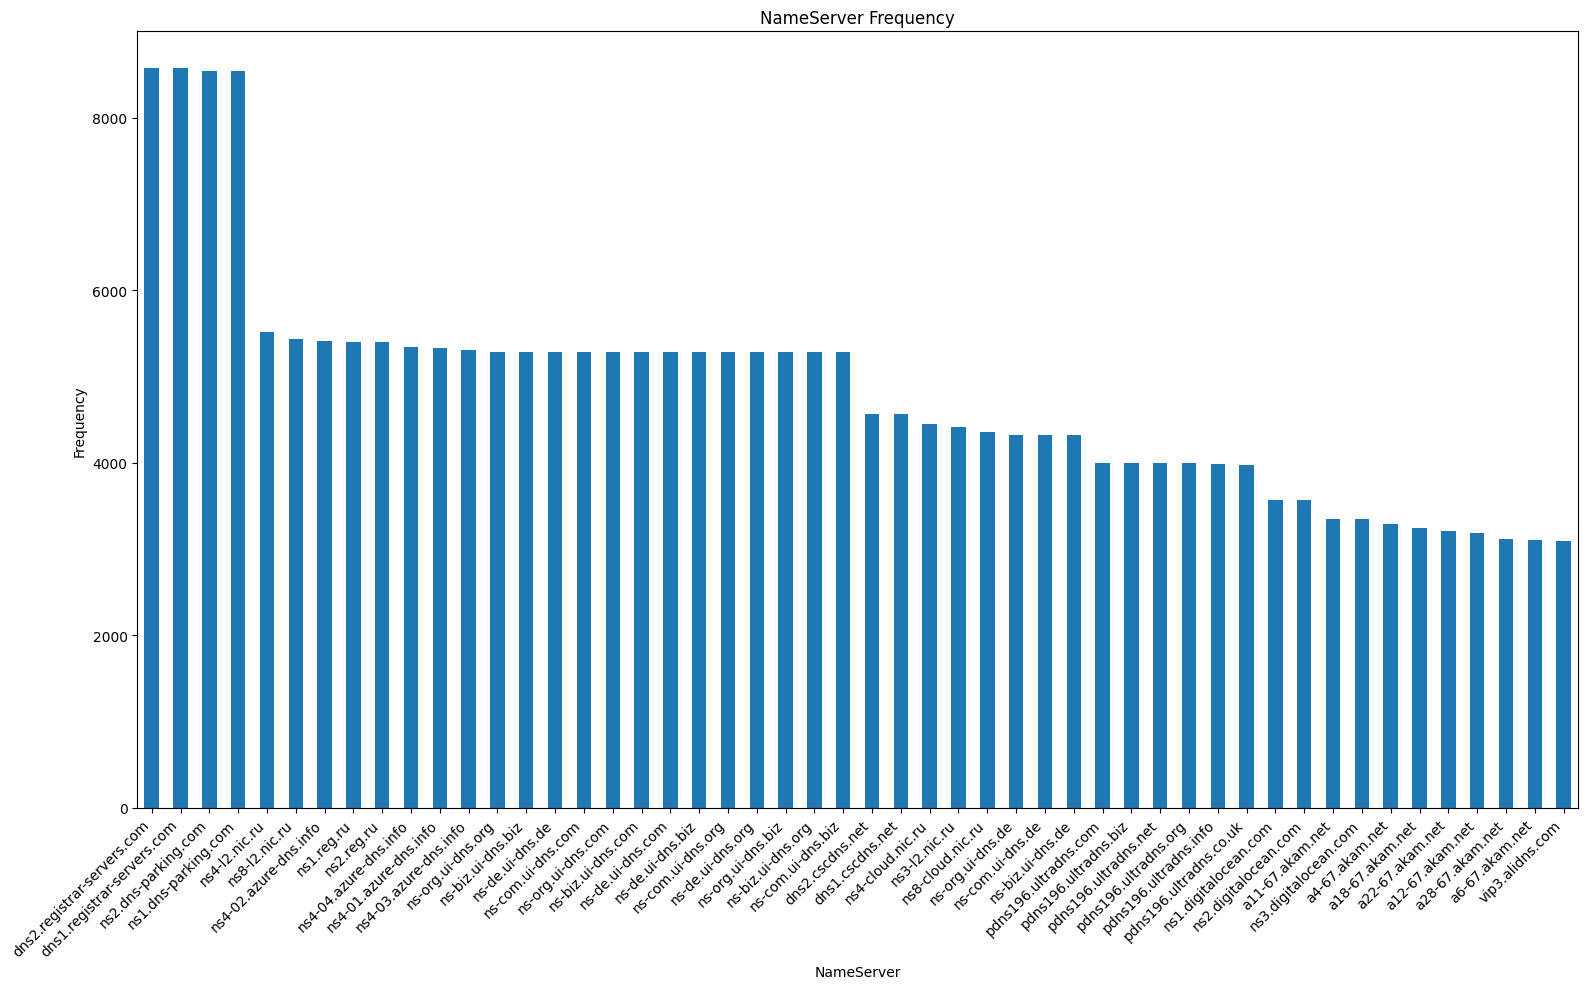

In [18]:
display(tranco_dns_infrastructure_df.shape)
infra_top20_unfilterd = tranco_dns_infrastructure_df.head(50)
infra_top20_unfilterd.plot(
    x="NameServer",
    y="Frequency",
    kind="bar",
    legend=False,
    figsize=(16, 10)
)

plt.xlabel("NameServer")
plt.ylabel("Frequency")
plt.title("NameServer Frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

##### infrastructure grouped 
groupd by First two levels of domain


This cell groups nameservers by their last two labels, such as provider domain, and counts how often each grouped name appears.


In [19]:
# DNS infrastructure grouped 
tranco_dns_infrastructure_grouped = {}

for row in concatinated_df.itertuples():
    for ns in row.domain_unique_ns:
        name = re.sub(r"^.*?([^.]+\.[^.]+)$", r"\1", ns)
        tranco_dns_infrastructure_grouped[name] = tranco_dns_infrastructure_grouped.get(name,0) + 1

tranco_dns_infrastructure_grouped_df = pd.DataFrame(list(tranco_dns_infrastructure_grouped.items()), columns=["NameServer", "Frequency"])  
tranco_dns_infrastructure_grouped_df = tranco_dns_infrastructure_grouped_df.sort_values("Frequency", ascending=False).reset_index(drop=True)

This cell displays the size of the grouped nameserver dataframe and plots the top 50 grouped nameservers.


(86469, 2)

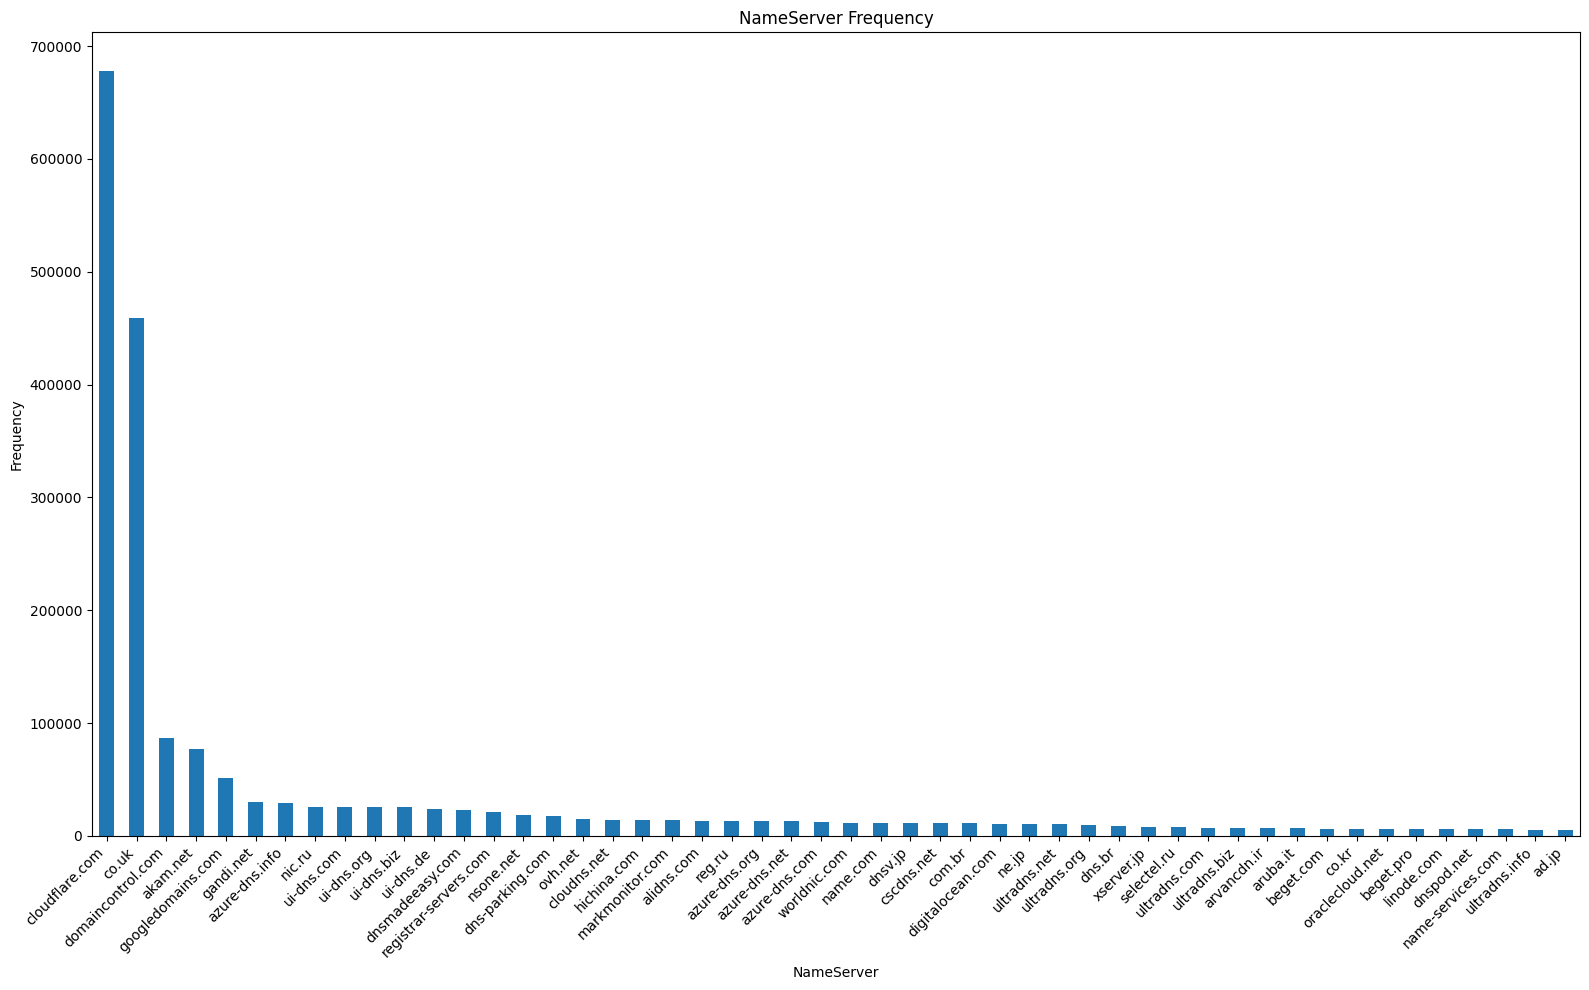

In [20]:
display(tranco_dns_infrastructure_grouped_df.shape)
infra_top20_grouped = tranco_dns_infrastructure_grouped_df.head(50)

infra_top20_grouped.plot(
    x="NameServer",
    y="Frequency",
    kind="bar",
    legend=False,
    figsize=(16, 10)
)

plt.xlabel("NameServer")
plt.ylabel("Frequency")
plt.title("NameServer Frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

##### infrastructure grouped 
Because of the co.uk umbrella problem. grouping not by keeping first two levels of domain but by removing most left label, the nth level domain

This cell removes the leftmost label from each nameserver to group related nameservers under a broader provider name.


In [21]:
# .co.uk umbrella
tranco_dns_infrastructure_removed_most_left_label = {}

for row in concatinated_df.itertuples():
    for ns in row.domain_unique_ns:
        name = ns.split(".", 1)[1]
        tranco_dns_infrastructure_removed_most_left_label[name] = tranco_dns_infrastructure_removed_most_left_label.get(name,0) + 1

tranco_dns_infrastructure__grouped_df = pd.DataFrame(list(tranco_dns_infrastructure_removed_most_left_label.items()), columns=["NameServer", "Frequency"])
tranco_dns_infrastructure__grouped_df = tranco_dns_infrastructure__grouped_df.sort_values("Frequency", ascending=False).reset_index(drop=True)

This cell displays the size of the broader grouped dataframe and plots the top 50 entries.


(106289, 2)

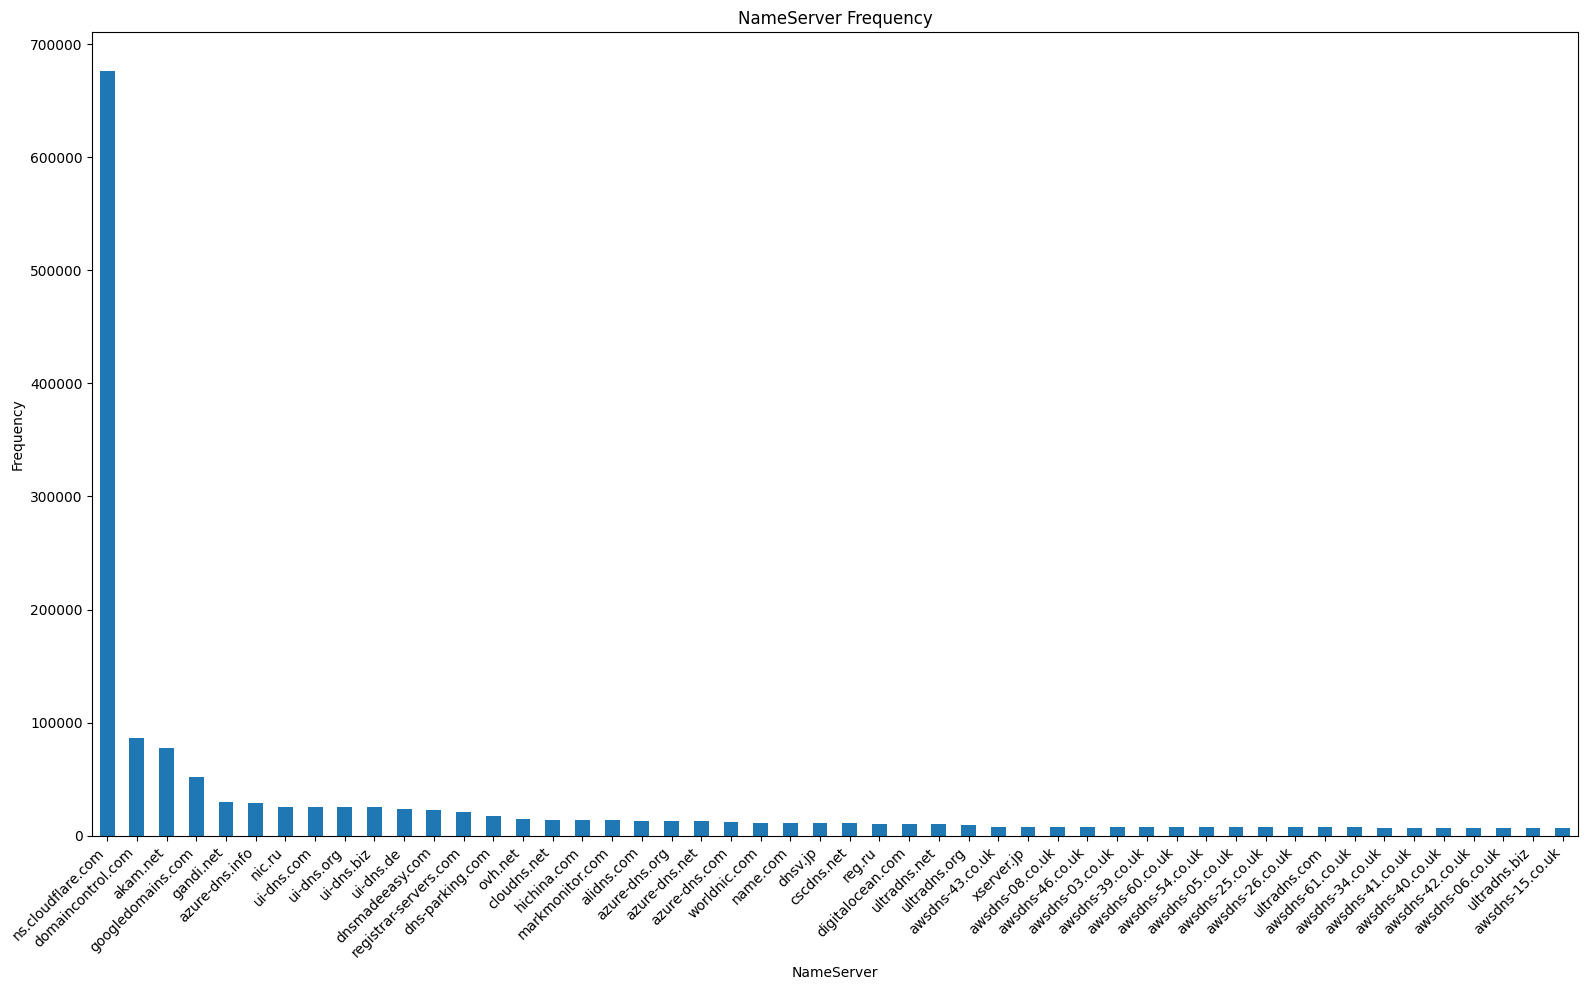

In [22]:
# .co.uk umbrella

display(tranco_dns_infrastructure__grouped_df.shape)
infra_top20__grouped = tranco_dns_infrastructure__grouped_df.head(50)
infra_top20__grouped.plot(
    x="NameServer",
    y="Frequency",
    kind="bar",
    legend=False,
    figsize=(16, 10)
)

plt.xlabel("NameServer")
plt.ylabel("Frequency")
plt.title("NameServer Frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

##### infrastructure grouped 
Because of the awsdns[number] umbrella problem. adding awsdns check

This cell groups nameservers after removing the leftmost label and normalizes AWS DNS names into one shared AWS pattern.


In [23]:
# aws
tranco_dns_infrastructure_removed_most_left_label = {}

for row in concatinated_df.itertuples():
    for ns in row.domain_unique_ns:
        name = ns.split(".", 1)[1]
        if name.startswith("awsdns"):
            name = "awsdns-[number].co.uk"
            tranco_dns_infrastructure_removed_most_left_label[name] = tranco_dns_infrastructure_removed_most_left_label.get(name,0) + 1
        else:
            tranco_dns_infrastructure_removed_most_left_label[name] = tranco_dns_infrastructure_removed_most_left_label.get(name,0) + 1


tranco_dns_infrastructure__grouped_df = pd.DataFrame(list(tranco_dns_infrastructure_removed_most_left_label.items()), columns=["NameServer", "Frequency"])
tranco_dns_infrastructure__grouped_df = tranco_dns_infrastructure__grouped_df.sort_values("Frequency", ascending=False).reset_index(drop=True)

This cell displays the final grouped dataframe size and plots the top 50 grouped nameserver providers.


(105516, 2)

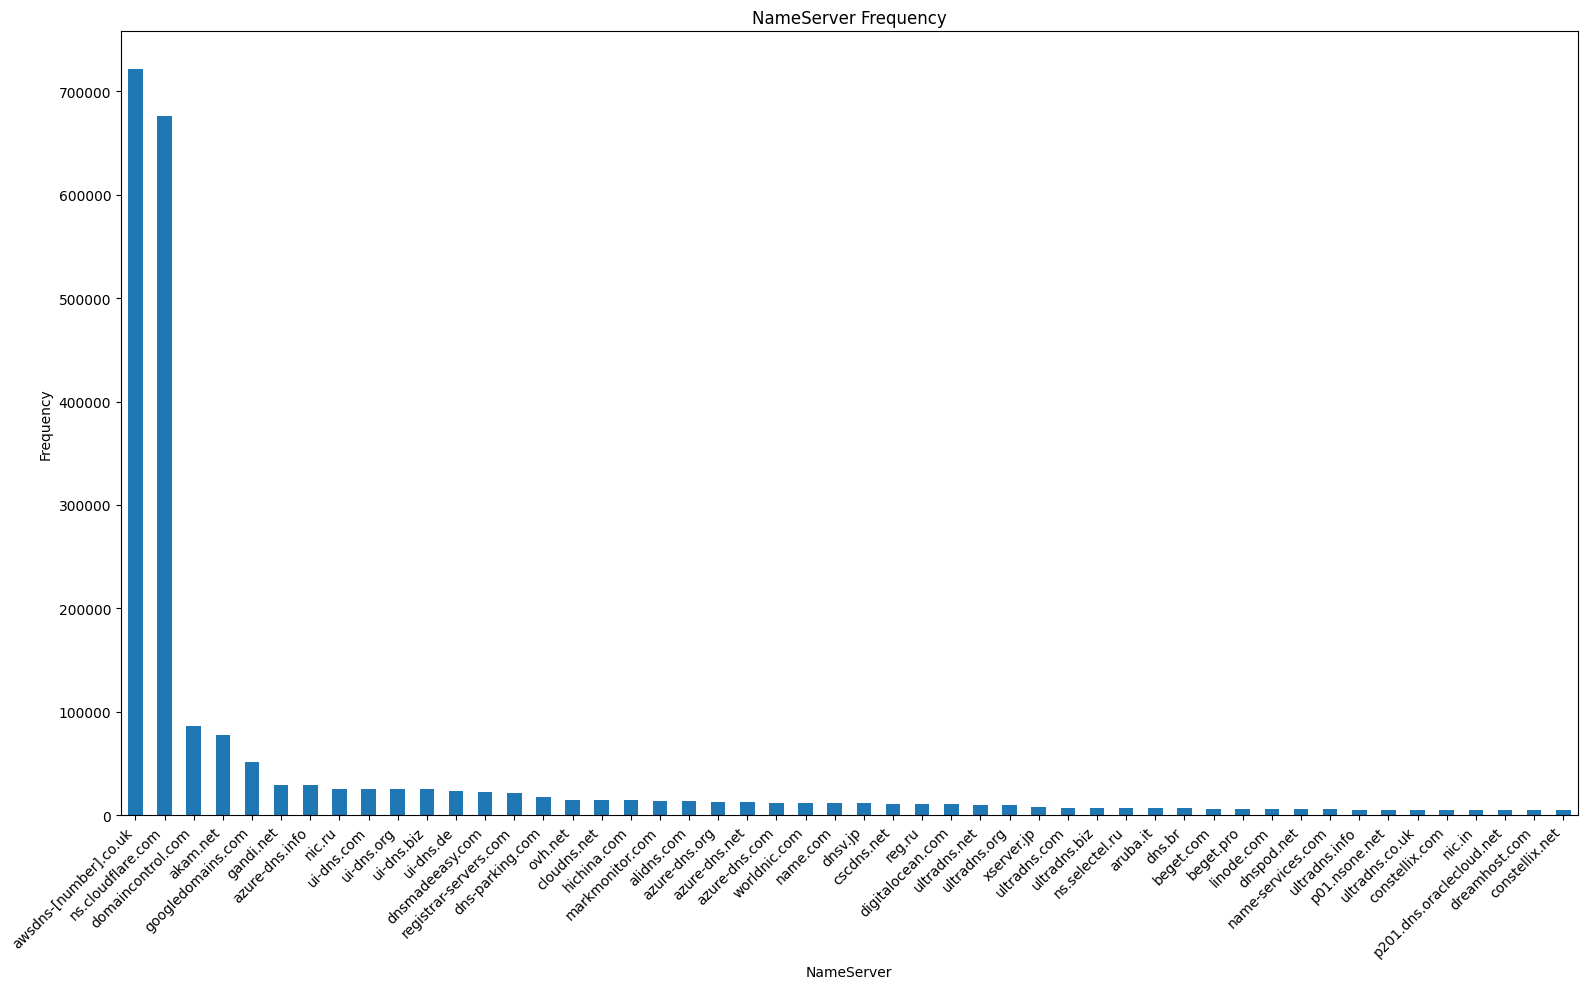

In [24]:
display(tranco_dns_infrastructure__grouped_df.shape)

infra_top20__grouped = tranco_dns_infrastructure__grouped_df.head(50)
infra_top20__grouped.plot(
    x="NameServer",
    y="Frequency",
    kind="bar",
    legend=False,
    figsize=(16, 10)
)

plt.xlabel("NameServer")
plt.ylabel("Frequency")
plt.title("NameServer Frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


##### infrastructure grouped 
Because of the co.uk umbrella problem. tld removal if the name are the same then just the second level subdomain 

This cell groups nameservers by removing both the leftmost label and the final TLD label, while combining AWS names into one infrastructure label.


In [25]:
# tld
tranco_dns_infrastructure_removed_most_left_label = {}

for row in concatinated_df.itertuples():
    for ns in row.domain_unique_ns:
        name = ns.split(".", 1)[1]
        if name.startswith("awsdns"):
            name = "awsdns-infrastructure"
            tranco_dns_infrastructure_removed_most_left_label[name] = tranco_dns_infrastructure_removed_most_left_label.get(name,0) + 1
        else:
            name = name.rsplit(".",1)[0] # I am omming TLD here 
            tranco_dns_infrastructure_removed_most_left_label[name] = tranco_dns_infrastructure_removed_most_left_label.get(name,0) + 1


tranco_dns_infrastructure__grouped_df = pd.DataFrame(list(tranco_dns_infrastructure_removed_most_left_label.items()), columns=["NameServer", "Frequency"])
tranco_dns_infrastructure__grouped_df = tranco_dns_infrastructure__grouped_df.sort_values("Frequency", ascending=False).reset_index(drop=True)

This cell displays the final grouped dataframe size and plots the top 50 grouped nameserver providers.


(98231, 2)

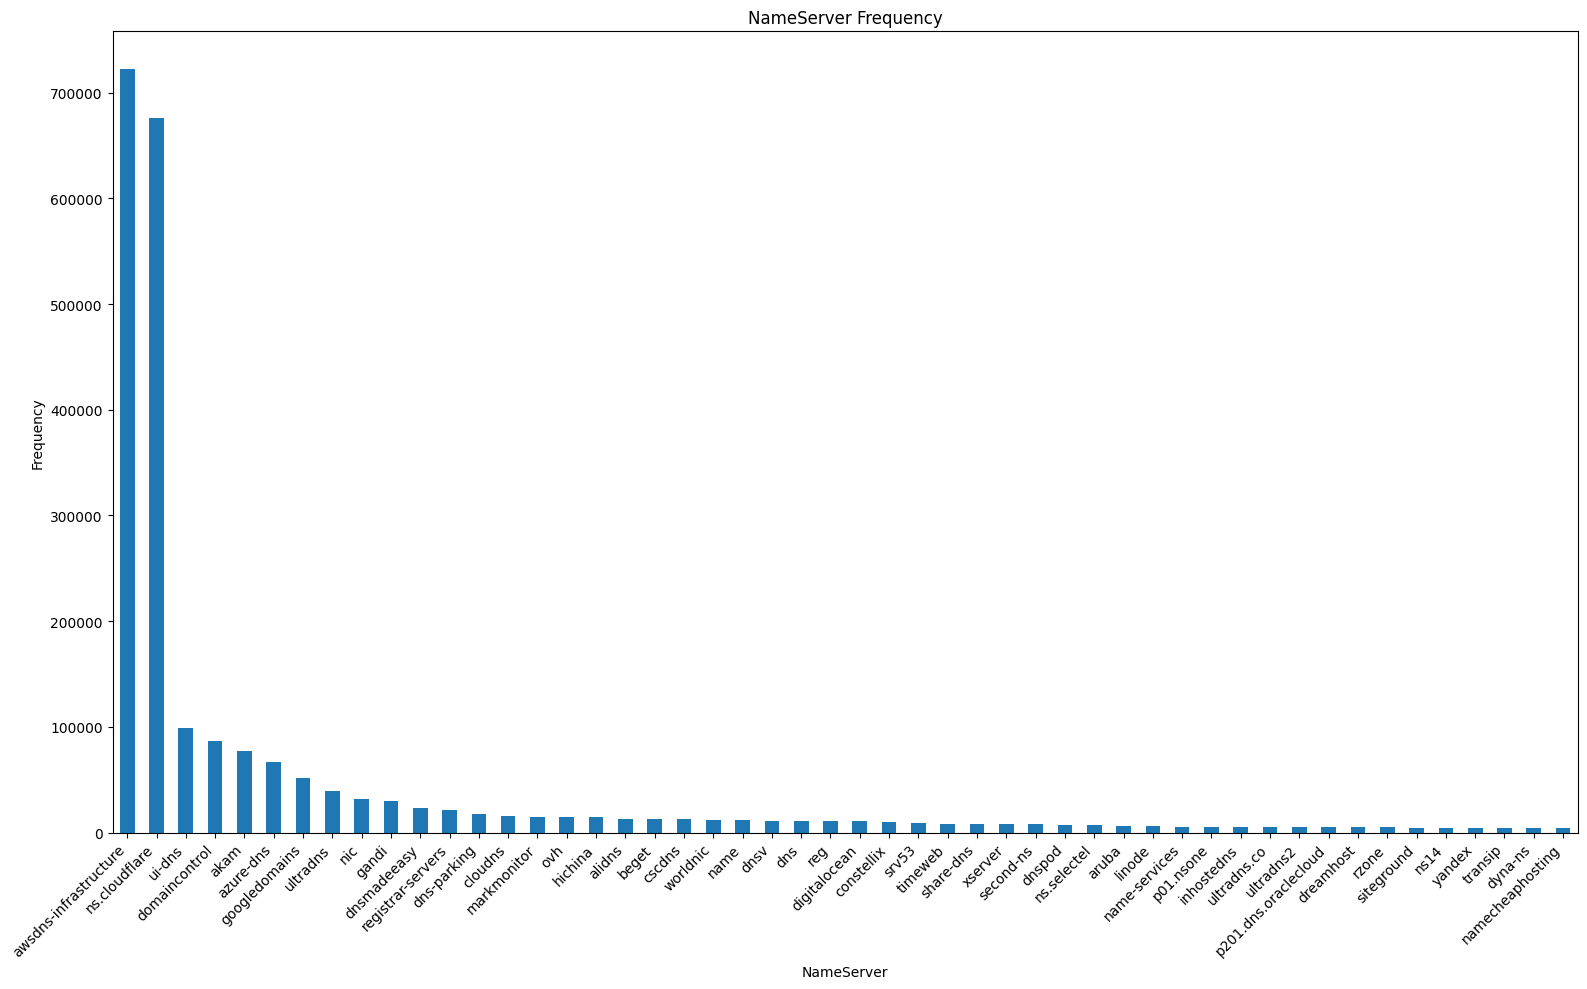

In [26]:
display(tranco_dns_infrastructure__grouped_df.shape)

infra_top20__grouped = tranco_dns_infrastructure__grouped_df.head(50)
infra_top20__grouped.plot(
    x="NameServer",
    y="Frequency",
    kind="bar",
    legend=False,
    figsize=(16, 10)
)

plt.xlabel("NameServer")
plt.ylabel("Frequency")
plt.title("NameServer Frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


##### Saving the infrastructure parquet

This cell saves the final grouped nameserver infrastructure dataframe as a parquet file for later analysis.


In [ ]:
try:
    out_dir = Path.cwd().parent / 'data' / 'result'/ 'dns_dependency'
    out_dir.mkdir(parents=True, exist_ok=True)

    out_path = out_dir / 'tranco_NS_Infrastructure.parquet'
    tranco_dns_infrastructure__grouped_df.to_parquet(out_path, index=False)
    
except Exception as e:
    print(f"failed:{e}")